In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [65]:
df_raw = pd.read_csv('/content/drive/MyDrive/CPE_KMUTT/Year3/Semester_1-68/CPE342_MachineLearning/CPE342_Lab/CPE342_Lab_Assignment2_TrainingModel_GradientDescent/A2.csv')
df_raw.head()

,X,Y
0,4.072280,0.981321
1,1.724332,1.124653
2,1.901981,1.042435
3,4.914068,0.949332
4,1.165868,1.186925


In [66]:
df = df_raw.sort_values(by='X')
df.head()

,X,Y
31,0.010773,1.970695
39,0.082322,1.863823
59,0.089938,1.911992
44,0.108369,1.843555
13,0.125230,1.804454


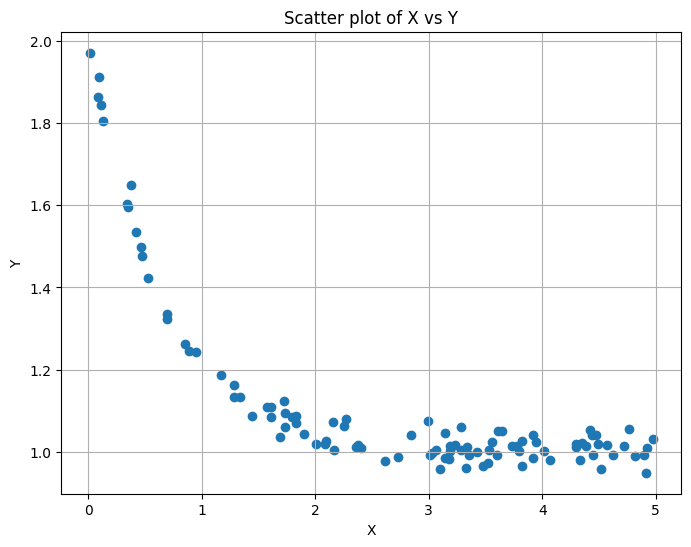

In [67]:
plt.figure(figsize=(8, 6))
plt.scatter(df['X'], df['Y'])
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter plot of X vs Y')
plt.grid(True)
plt.show()

# 1) Mean Squared Error (MSE) loss function
$$
\mathcal{L}(\theta) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

In [68]:
def loss_function(c0, c1, c2, x, y):
  n = len(df)
  y_hat = c0 + c1 * np.exp(c2 * x)
  loss = (1/(2*n)) * np.sum((y - y_hat)**2)
  return loss

# 2) Gradient of each coefficients
Compute partial derivatives of the loss function with respect to each coefficient

   
Model: $$\hat{y} = c_{0} + c_{1} e^{c_2 x}$$

Substituting the model:
$$
L = \frac{1}{2n} \sum_{i=1}^{n} (y_i - (c_0 + c_1 e^{c_2 x_i}))^2
$$

For any coefficient $\theta$, we use the chain rule:

$$
\frac{\partial L}{\partial \theta} = \frac{\partial}{\partial \theta} \left[ \frac{1}{2n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \right]
$$

$$
= \frac{1}{2n} \sum_{i=1}^{n} \frac{\partial}{\partial \theta} (y_i - \hat{y}_i)^2
$$

$$
= \frac{1}{2n} \sum_{i=1}^{n} 2(y_i - \hat{y}_i) \cdot \frac{\partial}{\partial \theta}(y_i - \hat{y}_i)
$$

$$
= \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \cdot \left(-\frac{\partial \hat{y}_i}{\partial \theta}\right)
$$

$$
= -\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \cdot \frac{\partial \hat{y}_i}{\partial \theta}
$$


---



## Find $\frac{\partial \hat{y}_i}{\partial c_0}$:

$$
\hat{y}_i = c_0 + c_1 e^{c_2 x_i}
$$

$$
\frac{\partial \hat{y}_i}{\partial c_0} = \frac{\partial}{\partial c_0}(c_0 + c_1 e^{c_2 x_i}) = 1 + 0 = 1
$$

Therefore:

$$
\frac{\partial L}{\partial c_0} = -\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \cdot 1
$$

$$
\boxed{\frac{\partial L}{\partial c_0} = -\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)}
$$
___

## Find $\frac{\partial \hat{y}_i}{\partial c_1}$:


$$
\hat{y}_i = c_0 + c_1 e^{c_2 x_i}
$$

$$
\frac{\partial \hat{y}_i}{\partial c_1} = \frac{\partial}{\partial c_1}(c_0 + c_1 e^{c_2 x_i}) = 0 + e^{c_2 x_i} = e^{c_2 x_i}
$$

Therefore:

$$
\frac{\partial L}{\partial c_1} = -\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \cdot e^{c_2 x_i}
$$

$$
\boxed{\frac{\partial L}{\partial c_1} = -\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) e^{c_2 x_i}}
$$
___

## Find $\frac{\partial \hat{y}_i}{\partial c_2}$:

$$
\hat{y}_i = c_0 + c_1 e^{c_2 x_i}
$$

$$
\frac{\partial \hat{y}_i}{\partial c_2} = \frac{\partial}{\partial c_2}(c_0 + c_1 e^{c_2 x_i})
$$

$$
= 0 + c_1 \frac{\partial}{\partial c_2}(e^{c_2 x_i})
$$

Using chain rule:
$$
\frac{\partial}{\partial c_2}(e^{c_2 x_i}) = e^{c_2 x_i} \cdot \frac{\partial}{\partial c_2}(c_2 x_i) = e^{c_2 x_i} \cdot x_i
$$

Therefore:
$$
\frac{\partial \hat{y}_i}{\partial c_2} = c_1 x_i e^{c_2 x_i}
$$

Substituting back:

$$
\frac{\partial L}{\partial c_2} = -\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \cdot (c_1 x_i e^{c_2 x_i})
$$

$$
\boxed{\frac{\partial L}{\partial c_2} = -\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) c_1 x_i e^{c_2 x_i}}
$$
___

## Complete set of gradients for gradient descent:

$$
\begin{align}
\frac{\partial L}{\partial c_0} &= -\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \\[10pt]
\frac{\partial L}{\partial c_1} &= -\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) e^{c_2 x_i} \\[10pt]
\frac{\partial L}{\partial c_2} &= -\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) c_1 x_i e^{c_2 x_i}
\end{align}
$$

where $\hat{y}_i = c_0 + c_1 e^{c_2 x_i}$

and $(y_i - \hat{y}_i)$ is the prediction error.

In [69]:
def compute_gradients(c0, c1, c2, x, y):
  n = len(df)

  # Compute predictions and errors
  exp_term = np.exp(c2 * x)
  y_hat = c0 + c1 * exp_term
  error = y - y_hat

  # Compute gradients
  grad_c0 = -(1/n) * np.sum(error)
  grad_c1 = -(1/n) * np.sum(error * exp_term)
  grad_c2 = -(1/n) * np.sum(error * c1 * x * exp_term)

  return grad_c0, grad_c1, grad_c2

# 3) Update rules
Update coefficients using gradient descent rule
    
Update rule: $$θ_{new} = θ_{old} - α ∇θ$$
where $α$ is the learning rate and $∇θ$ is the gradient

$$
c_{0new} = c_{0old} - α \frac{\partial L}{\partial c_{0}}
$$

$$
c_{1new} = c_{1old} - α \frac{\partial L}{\partial c_{1}}
$$

$$
c_{2new} = c_{2old} - α \frac{\partial L}{\partial c_{2}}
$$

Args:
* $c_0, c_1, c_2$: current coefficients
* grad_c0, grad_c1, grad_c2: gradients
* learning_rate: step size

In [70]:
def update_coefficients(c0, c1, c2, grad_c0, grad_c1, grad_c2, learning_rate):
  new_c0 = c0 - learning_rate * grad_c0
  new_c1 = c1 - learning_rate * grad_c1
  new_c2 = c2 - learning_rate * grad_c2

  return new_c0, new_c1, new_c2

In [71]:
def gradient_descent(x, y, initial_c0=1.0, initial_c1=1.0, initial_c2=1.0, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
  # Initialize coefficients
  c0, c1, c2 = initial_c0, initial_c1, initial_c2

  # Track history
  loss_history = []
  coeff_history = {'c0': [], 'c1': [], 'c2': []}

  print(f"\nStarting gradient descent with:")
  print(f"Initial coefficients: c0={c0:.3f}, c1={c1:.3f}, c2={c2:.3f}")
  print(f"Learning rate: {learning_rate}")
  print(f"Max iterations: {max_iterations}")

  for iteration in range(max_iterations):
    # Compute current loss
    current_loss = loss_function(c0, c1, c2, x, y)
    loss_history.append(current_loss)

    # Store current coefficients
    coeff_history['c0'].append(c0)
    coeff_history['c1'].append(c1)
    coeff_history['c2'].append(c2)

    # Compute gradients
    grad_c0, grad_c1, grad_c2 = compute_gradients(c0, c1, c2, x, y)

    # Update coefficients
    c0, c1, c2 = update_coefficients(c0, c1, c2, grad_c0, grad_c1, grad_c2, learning_rate)

    # Print progress every 100 iterations
    if iteration % 100 == 0:
      print(f"Iteration {iteration}: Loss = {current_loss:.6f}, "
        f"c0={c0:.3f}, c1={c1:.3f}, c2={c2:.3f}")

    # Check for convergence
    if iteration > 0 and abs(loss_history[-1] - loss_history[-2]) < tolerance:
      print(f"Converged at iteration {iteration}")
      break

  final_coefficients = [c0, c1, c2]
  return final_coefficients, loss_history, coeff_history

# 4) Implement the gradient descent using the given data

In [72]:
final_coeffs, loss_hist, coeff_hist = gradient_descent(
    df['X'], df['Y'],
    initial_c0=0.5, initial_c1=0.5, initial_c2=0.1,
    learning_rate=1,  # Small learning rate for stability
    max_iterations=2000
)

print(f"\nFinal coefficients:")
print(f"c0 = {final_coeffs[0]:.6f}")
print(f"c1 = {final_coeffs[1]:.6f}")
print(f"c2 = {final_coeffs[2]:.6f}")
print(f"Final loss = {loss_hist[-1]:.6f}")


Starting gradient descent with:
Initial coefficients: c0=0.500, c1=0.500, c2=0.100
Learning rate: 1
Max iterations: 2000
Iteration 0: Loss = 0.046463, c0=0.456, c1=0.394, c2=-0.281
Iteration 100: Loss = 0.001110, c0=0.969, c1=0.890, c2=-1.031
Iteration 200: Loss = 0.000580, c0=0.987, c1=0.941, c2=-1.247
Converged at iteration 269

Final coefficients:
c0 = 0.992665
c1 = 0.958671
c2 = -1.329637
Final loss = 0.000474


# 5) Visualization

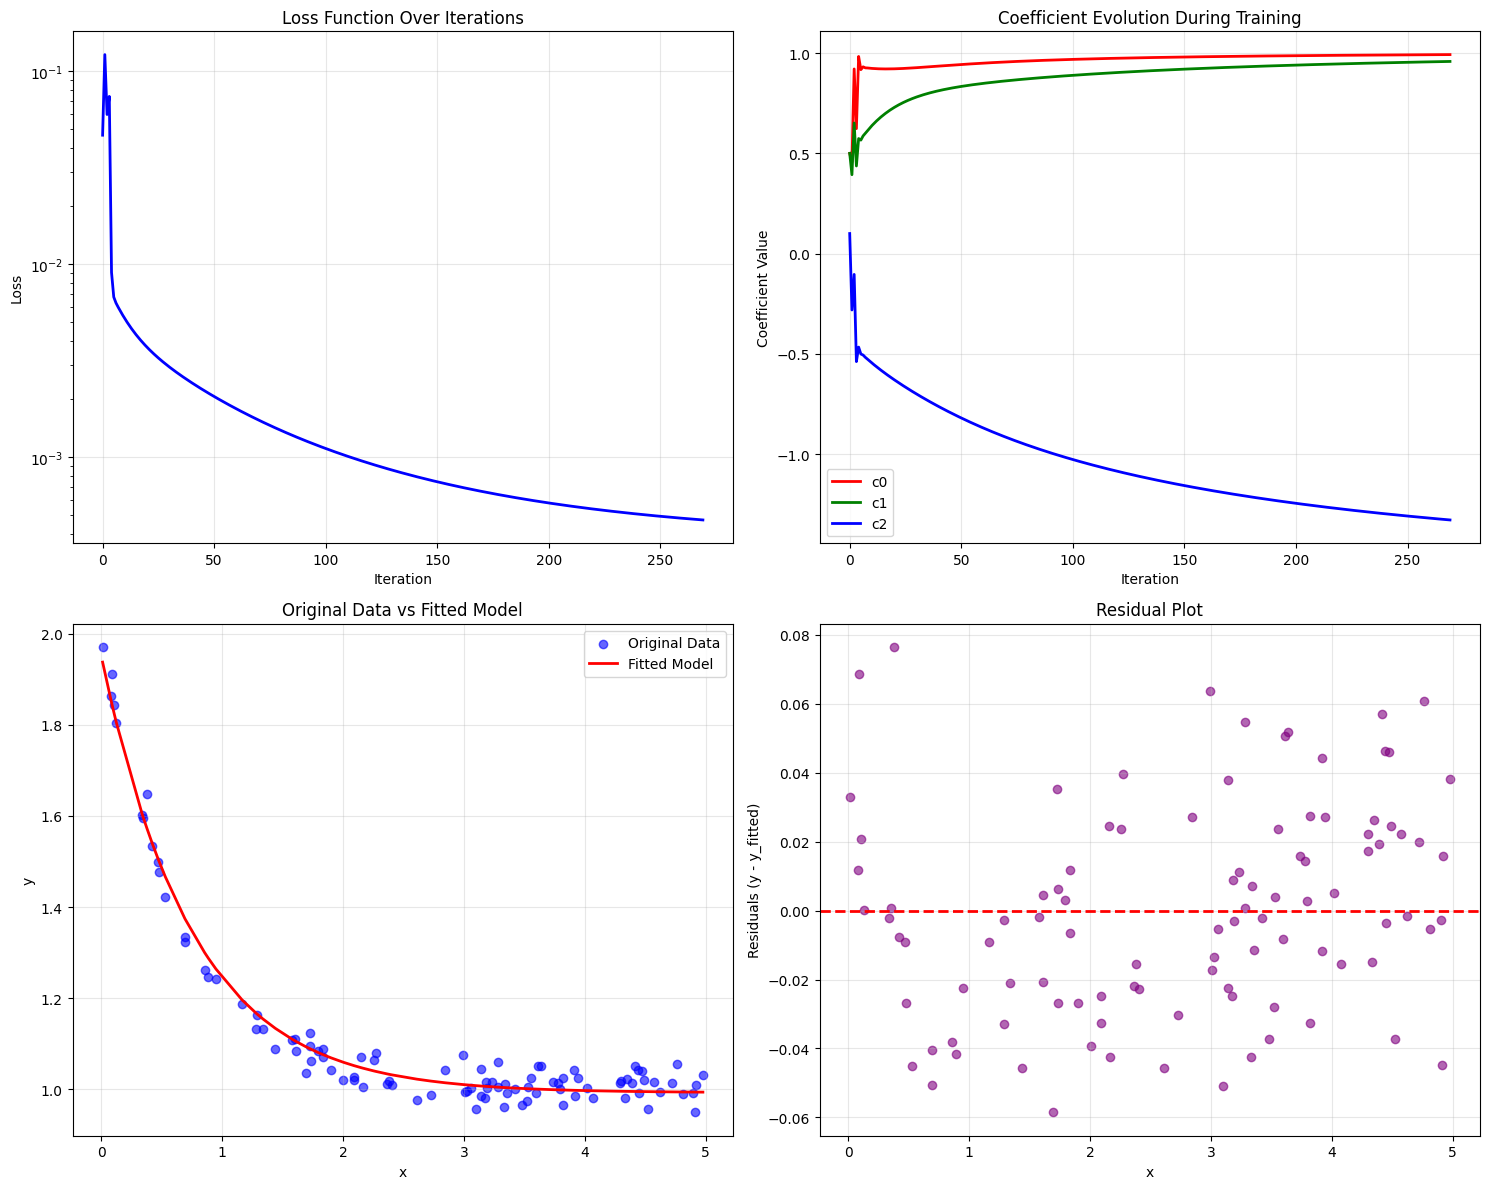


SUMMARY:
Fitted coefficients: c0=0.992665, c1=0.958671, c2=-1.329637
Number of iterations: 270
Final loss: 0.000474
Initial loss: 0.046463
Loss reduction: 98.98%
R-squared: 0.981770


In [73]:
# Create subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Loss over iterations
ax1.plot(loss_hist, 'b-', linewidth=2)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Function Over Iterations')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')  # Log scale to see convergence better

# Plot 2: Coefficient evolution
ax2.plot(coeff_hist['c0'], 'r-', label='c0', linewidth=2)
ax2.plot(coeff_hist['c1'], 'g-', label='c1', linewidth=2)
ax2.plot(coeff_hist['c2'], 'b-', label='c2', linewidth=2)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Coefficient Value')
ax2.set_title('Coefficient Evolution During Training')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Original data vs fitted model
y_fitted = final_coeffs[0] + final_coeffs[1] * np.exp(final_coeffs[2] * df['X'])
ax3.scatter(df['X'], df['Y'], alpha=0.6, color='blue', label='Original Data')
ax3.plot(df['X'], y_fitted, 'r-', linewidth=2, label='Fitted Model')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('Original Data vs Fitted Model')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Residuals
residuals = df['Y'] - y_fitted
ax4.scatter(df['X'], residuals, alpha=0.6, color='purple')
ax4.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('x')
ax4.set_ylabel('Residuals (y - y_fitted)')
ax4.set_title('Residual Plot')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSUMMARY:")
# print(f"True coefficients (used to generate data): c0={true_c0}, c1={true_c1}, c2={true_c2}")
print(f"Fitted coefficients: c0={final_coeffs[0]:.6f}, c1={final_coeffs[1]:.6f}, c2={final_coeffs[2]:.6f}")
print(f"Number of iterations: {len(loss_hist)}")
print(f"Final loss: {loss_hist[-1]:.6f}")
print(f"Initial loss: {loss_hist[0]:.6f}")
print(f"Loss reduction: {((loss_hist[0] - loss_hist[-1])/loss_hist[0]*100):.2f}%")

# Calculate R-squared
ss_res = np.sum((df['Y'] - y_fitted)**2)
ss_tot = np.sum((df['Y'] - np.mean(df['Y']))**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"R-squared: {r_squared:.6f}")